<a href="https://colab.research.google.com/github/aabyyaann/scikit-learn-Cookbook/blob/main/Chapter6_Classification_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 6 - Classification Models

Notebook ini membahas konsep dasar **classification** pada scikit-learn.  
Classification adalah tugas machine learning untuk memprediksi **label kategori** dari suatu data.

Pada chapter ini, kita akan mempelajari:
- pengertian klasifikasi,
- persiapan dataset,
- training beberapa model klasifikasi,
- evaluasi performa model,
- perbandingan beberapa algoritma klasifikasi.

Dataset yang digunakan adalah **Breast Cancer Wisconsin Dataset** dari scikit-learn.

## 1. Tujuan Pembelajaran

Setelah menyelesaikan notebook ini, kita diharapkan dapat:
1. Memahami perbedaan masalah klasifikasi dengan regresi.
2. Menyiapkan data untuk tugas klasifikasi.
3. Melatih beberapa model klasifikasi dengan scikit-learn.
4. Mengevaluasi model menggunakan metrik seperti accuracy, confusion matrix, dan ROC-AUC.
5. Membandingkan performa beberapa algoritma klasifikasi.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

sns.set_style("whitegrid")
print("Library berhasil diimport.")

Library berhasil diimport.


## 2. Memuat Dataset

Pada notebook ini kita menggunakan **Breast Cancer Wisconsin Dataset** yang tersedia langsung di scikit-learn.

Dataset ini berisi fitur-fitur numerik hasil pengukuran sel tumor, dan targetnya adalah:
- **0 = malignant** → tumor ganas
- **1 = benign** → tumor jinak

Karena target berupa kategori, maka permasalahan ini termasuk **supervised learning - classification**.

In [4]:
cancer = load_breast_cancer()

X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y = pd.Series(cancer.target, name="target")

print("Shape fitur :", X.shape)
print("Shape target:", y.shape)
print()
print("5 data pertama:")
display(X.head())

print("Distribusi target:")
print(y.value_counts())

Shape fitur : (569, 30)
Shape target: (569,)

5 data pertama:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Distribusi target:
target
1    357
0    212
Name: count, dtype: int64


## 3. Memahami Struktur Data

Sebelum membangun model, kita perlu memahami struktur data:
- jumlah baris dan kolom,
- nama fitur,
- tipe data,
- distribusi target,
- serta memastikan tidak ada missing value.

Langkah ini penting agar kita tahu apakah data siap digunakan atau masih memerlukan preprocessing tambahan.

In [5]:
print("Nama target:", cancer.target_names)
print()
X.info()

Nama target: ['malignant' 'benign']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    fl

In [6]:
print("Jumlah missing value per kolom:")
display(X.isnull().sum().head())
print("\nTotal missing value:", X.isnull().sum().sum())

Jumlah missing value per kolom:


,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0



Total missing value: 0


In [7]:
display(X.describe().T.head(10))

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.98100,11.70000,13.37000,15.78000,28.11000
mean texture,569.0,19.289649,4.301036,9.71000,16.17000,18.84000,21.80000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.79000,75.17000,86.24000,104.10000,188.50000
mean area,569.0,654.889104,351.914129,143.50000,420.30000,551.10000,782.70000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.05263,0.08637,0.09587,0.10530,0.16340
mean compactness,569.0,0.104341,0.052813,0.01938,0.06492,0.09263,0.13040,0.34540
mean concavity,569.0,0.088799,0.079720,0.00000,0.02956,0.06154,0.13070,0.42680
mean concave points,569.0,0.048919,0.038803,0.00000,0.02031,0.03350,0.07400,0.20120
mean symmetry,569.0,0.181162,0.027414,0.10600,0.16190,0.17920,0.19570,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.04996,0.05770,0.06154,0.06612,0.09744


## 4. Visualisasi Target

Sebelum training model, kita cek distribusi target terlebih dahulu.  
Hal ini penting untuk mengetahui apakah dataset relatif seimbang atau tidak.

Pada kasus klasifikasi, distribusi target yang sangat timpang dapat memengaruhi performa model.

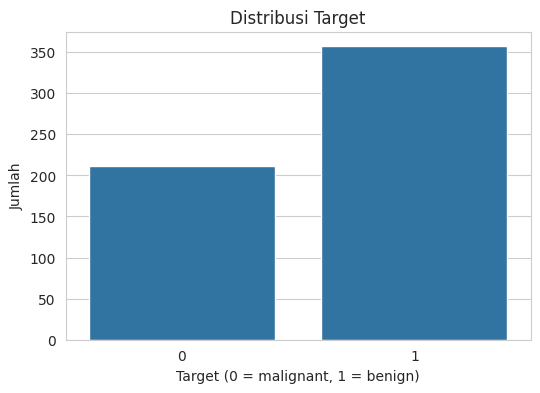

In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title("Distribusi Target")
plt.xlabel("Target (0 = malignant, 1 = benign)")
plt.ylabel("Jumlah")
plt.show()

## 5. Korelasi Antar Fitur

Kita juga dapat melihat hubungan antar fitur menggunakan heatmap korelasi.  
Visualisasi ini membantu memahami apakah ada fitur-fitur yang sangat berkorelasi satu sama lain.

Walaupun tidak selalu wajib, analisis korelasi sering berguna dalam tahap eksplorasi data.

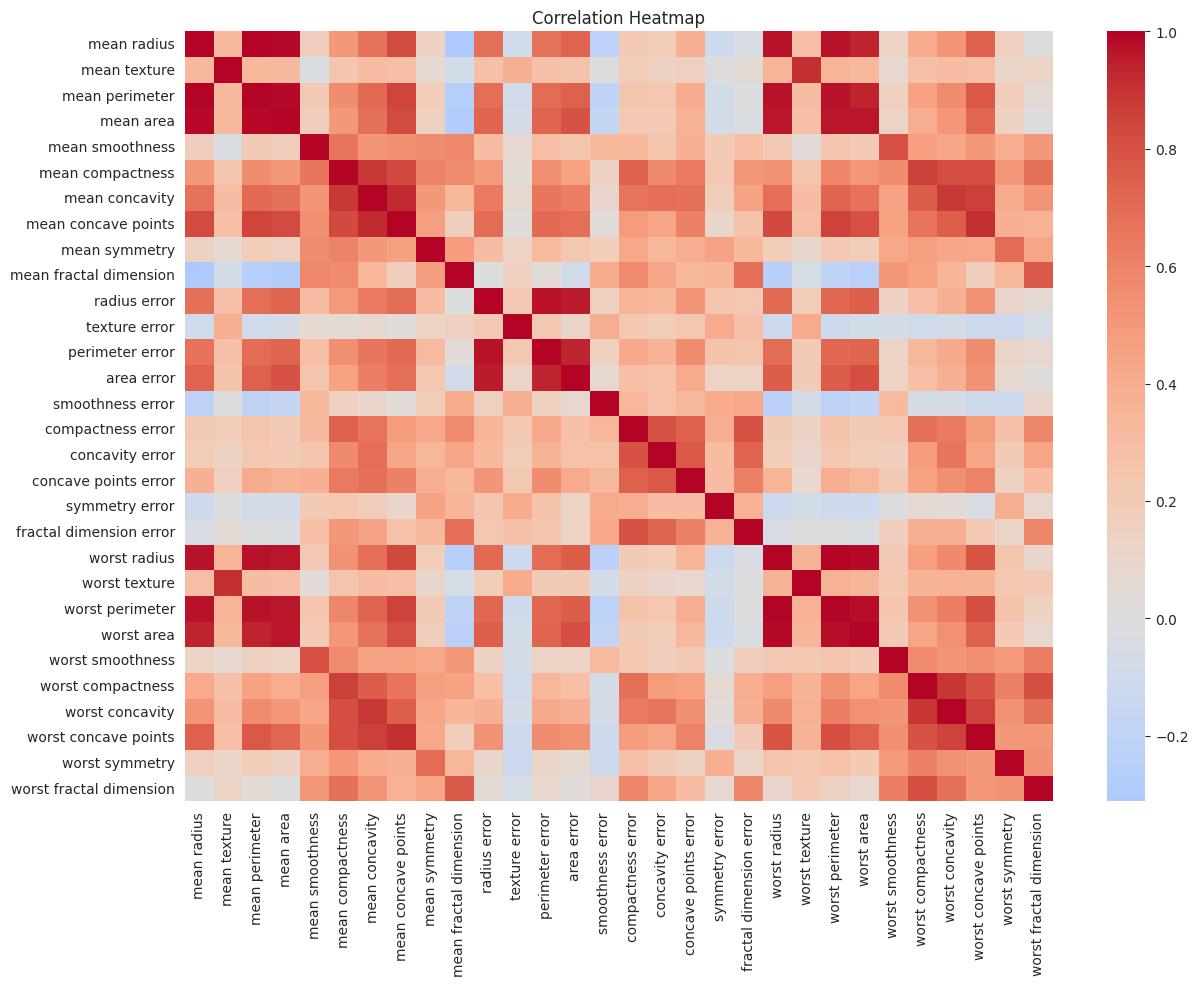

In [9]:
plt.figure(figsize=(14, 10))
corr = X.corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

## 6. Split Data

Data dibagi menjadi:
- **training set** → digunakan untuk melatih model
- **test set** → digunakan untuk menguji performa model pada data yang belum pernah dilihat sebelumnya

Pembagian ini penting agar evaluasi model lebih adil dan dapat menggambarkan kemampuan generalisasi model.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (455, 30)
X_test : (114, 30)
y_train: (455,)
y_test : (114,)


## 7. Feature Scaling

Beberapa algoritma klasifikasi seperti:
- Logistic Regression
- KNN
- SVM

sangat sensitif terhadap skala fitur.  
Karena itu kita menggunakan **StandardScaler** agar fitur memiliki skala yang lebih seimbang.

Model berbasis pohon seperti Decision Tree dan Random Forest umumnya tidak terlalu bergantung pada scaling, tetapi untuk model lain scaling sangat membantu.

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling selesai.")
print("Shape X_train_scaled:", X_train_scaled.shape)
print("Shape X_test_scaled :", X_test_scaled.shape)

Scaling selesai.
Shape X_train_scaled: (455, 30)
Shape X_test_scaled : (114, 30)


# 8. Logistic Regression

**Logistic Regression** adalah salah satu model baseline yang sangat umum untuk klasifikasi.  
Meskipun namanya mengandung kata *regression*, model ini digunakan untuk **classification**.

Model ini bekerja dengan memodelkan probabilitas suatu data termasuk ke kelas tertentu.  
Untuk klasifikasi biner, output akhirnya biasanya berupa probabilitas yang kemudian diubah menjadi label kelas.

In [12]:
logreg = LogisticRegression(max_iter=5000, random_state=42)
logreg.fit(X_train_scaled, y_train)

y_pred_logreg = logreg.predict(X_test_scaled)
y_prob_logreg = logreg.predict_proba(X_test_scaled)[:, 1]

acc_logreg = accuracy_score(y_test, y_pred_logreg)
auc_logreg = roc_auc_score(y_test, y_prob_logreg)

print("Logistic Regression")
print("Accuracy :", round(acc_logreg, 4))
print("ROC-AUC  :", round(auc_logreg, 4))

Logistic Regression
Accuracy : 0.9825
ROC-AUC  : 0.9954


In [13]:
print("Classification Report - Logistic Regression")
print(classification_report(y_test, y_pred_logreg, target_names=cancer.target_names))

Classification Report - Logistic Regression
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



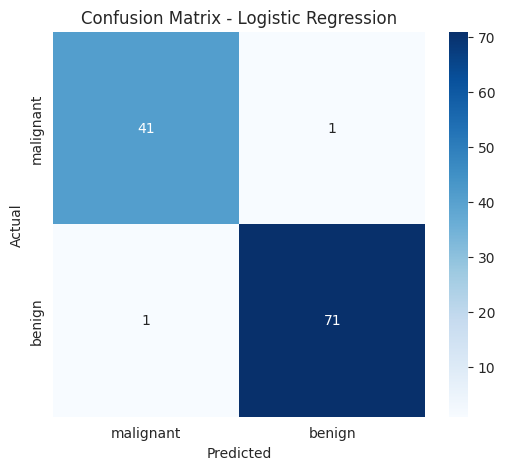

In [14]:
cm = confusion_matrix(y_test, y_pred_logreg)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=cancer.target_names,
            yticklabels=cancer.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

## 9. K-Nearest Neighbors (KNN)

**KNN** adalah algoritma yang memprediksi kelas suatu data berdasarkan tetangga terdekatnya.  
Model ini tidak membangun persamaan eksplisit, tetapi mengandalkan jarak antar data.

Karena berbasis jarak, KNN sangat sensitif terhadap skala fitur.  
Itulah sebabnya scaling menjadi langkah penting sebelum menggunakan KNN.

In [15]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
y_prob_knn = knn.predict_proba(X_test_scaled)[:, 1]

acc_knn = accuracy_score(y_test, y_pred_knn)
auc_knn = roc_auc_score(y_test, y_prob_knn)

print("K-Nearest Neighbors")
print("Accuracy :", round(acc_knn, 4))
print("ROC-AUC  :", round(auc_knn, 4))

K-Nearest Neighbors
Accuracy : 0.9561
ROC-AUC  : 0.9788


In [16]:
print("Classification Report - KNN")
print(classification_report(y_test, y_pred_knn, target_names=cancer.target_names))

Classification Report - KNN
              precision    recall  f1-score   support

   malignant       0.95      0.93      0.94        42
      benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



## 10. Decision Tree

**Decision Tree** membagi data ke dalam serangkaian aturan berbentuk pohon keputusan.  
Model ini cukup mudah dipahami karena hasilnya dapat dijelaskan sebagai urutan keputusan.

Kelemahan utamanya adalah decision tree mudah mengalami **overfitting** jika dibiarkan tumbuh terlalu dalam.  
Karena itu kita sering membatasi parameter seperti `max_depth`.

In [17]:
tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)
y_prob_tree = tree.predict_proba(X_test)[:, 1]

acc_tree = accuracy_score(y_test, y_pred_tree)
auc_tree = roc_auc_score(y_test, y_prob_tree)

print("Decision Tree")
print("Accuracy :", round(acc_tree, 4))
print("ROC-AUC  :", round(auc_tree, 4))

Decision Tree
Accuracy : 0.9386
ROC-AUC  : 0.9342


In [18]:
print("Classification Report - Decision Tree")
print(classification_report(y_test, y_pred_tree, target_names=cancer.target_names))

Classification Report - Decision Tree
              precision    recall  f1-score   support

   malignant       0.91      0.93      0.92        42
      benign       0.96      0.94      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



## 11. Random Forest

**Random Forest** adalah kumpulan banyak decision tree yang dilatih pada subset data dan subset fitur yang berbeda.  
Pendekatan ini termasuk **ensemble learning**.

Keunggulan Random Forest:
- lebih stabil dibanding satu decision tree,
- cenderung memiliki generalisasi lebih baik,
- dapat memberikan feature importance.

In [19]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

acc_rf = accuracy_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest")
print("Accuracy :", round(acc_rf, 4))
print("ROC-AUC  :", round(auc_rf, 4))

Random Forest
Accuracy : 0.9474
ROC-AUC  : 0.994


In [20]:
print("Classification Report - Random Forest")
print(classification_report(y_test, y_pred_rf, target_names=cancer.target_names))

Classification Report - Random Forest
              precision    recall  f1-score   support

   malignant       0.93      0.93      0.93        42
      benign       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



## 12. Support Vector Machine (SVM)

**Support Vector Machine (SVM)** berusaha mencari batas pemisah terbaik antar kelas.  
Untuk data yang tidak terpisah secara linear, SVM dapat menggunakan **kernel trick** agar mampu membentuk decision boundary yang lebih fleksibel.

SVM sering memberikan performa tinggi, tetapi:
- sensitif terhadap skala fitur,
- bisa lebih lambat pada dataset besar,
- memerlukan tuning parameter seperti `C` dan `kernel`.

In [21]:
svm = SVC(C=1.0, kernel="rbf", probability=True, random_state=42)
svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)
y_prob_svm = svm.predict_proba(X_test_scaled)[:, 1]

acc_svm = accuracy_score(y_test, y_pred_svm)
auc_svm = roc_auc_score(y_test, y_prob_svm)

print("Support Vector Machine")
print("Accuracy :", round(acc_svm, 4))
print("ROC-AUC  :", round(auc_svm, 4))

Support Vector Machine
Accuracy : 0.9825
ROC-AUC  : 0.995


In [22]:
print("Classification Report - SVM")
print(classification_report(y_test, y_pred_svm, target_names=cancer.target_names))

Classification Report - SVM
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



## 13. Membandingkan Semua Model

Setelah melatih beberapa model, langkah berikutnya adalah membandingkan performanya.  
Kita akan menggunakan dua metrik utama:
- **Accuracy** → proporsi prediksi yang benar
- **ROC-AUC** → kemampuan model membedakan kelas positif dan negatif

Dengan tabel perbandingan, kita dapat melihat model mana yang paling baik pada dataset ini.

In [23]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest",
        "SVM"
    ],
    "Accuracy": [
        acc_logreg,
        acc_knn,
        acc_tree,
        acc_rf,
        acc_svm
    ],
    "ROC_AUC": [
        auc_logreg,
        auc_knn,
        auc_tree,
        auc_rf,
        auc_svm
    ]
})

results = results.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
results

,Model,Accuracy,ROC_AUC
0,Logistic Regression,0.982456,0.995370
1,SVM,0.982456,0.995040
2,KNN,0.956140,0.978836
3,Random Forest,0.947368,0.994048
4,Decision Tree,0.938596,0.934193


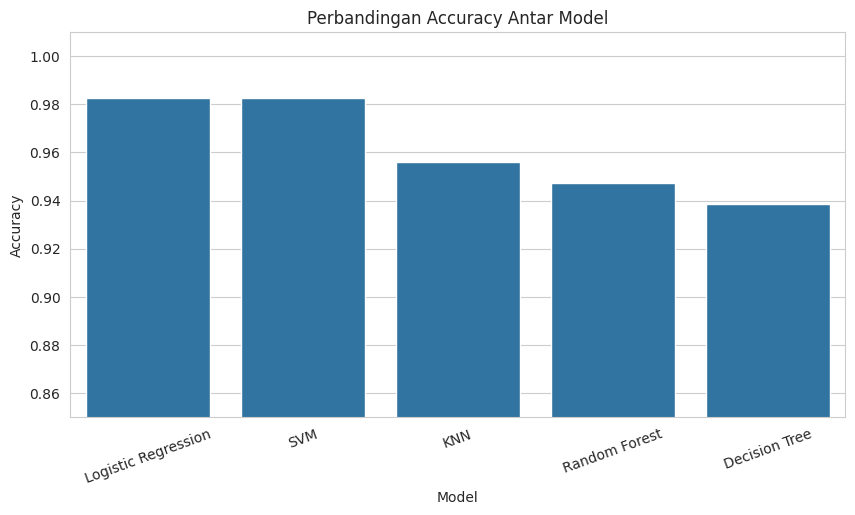

In [24]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results, x="Model", y="Accuracy")
plt.title("Perbandingan Accuracy Antar Model")
plt.ylim(0.85, 1.01)
plt.xticks(rotation=20)
plt.show()

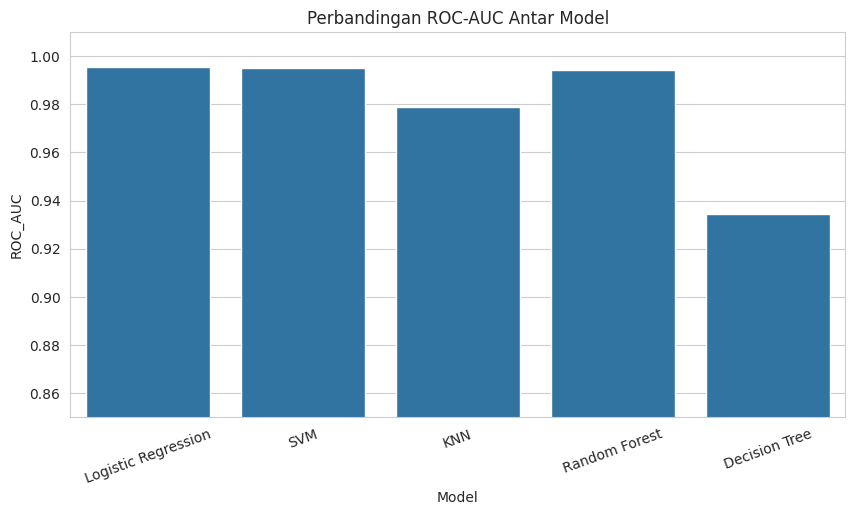

In [25]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results, x="Model", y="ROC_AUC")
plt.title("Perbandingan ROC-AUC Antar Model")
plt.ylim(0.85, 1.01)
plt.xticks(rotation=20)
plt.show()

## 14. ROC Curve

ROC Curve memperlihatkan trade-off antara:
- **True Positive Rate**
- **False Positive Rate**

Kurva ROC membantu membandingkan model secara lebih detail, terutama pada klasifikasi biner.  
Semakin besar nilai **AUC**, biasanya semakin baik kemampuan model dalam membedakan kelas.

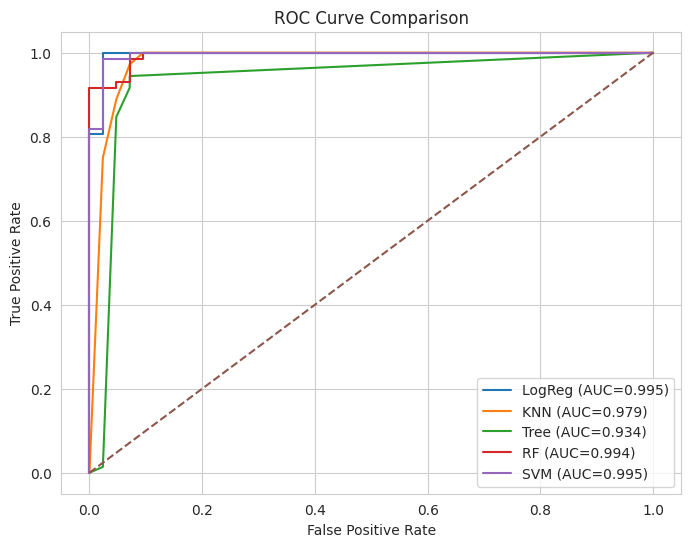

In [26]:
fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_prob_logreg)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)

plt.figure(figsize=(8, 6))
plt.plot(fpr_logreg, tpr_logreg, label=f"LogReg (AUC={auc_logreg:.3f})")
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC={auc_knn:.3f})")
plt.plot(fpr_tree, tpr_tree, label=f"Tree (AUC={auc_tree:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"RF (AUC={auc_rf:.3f})")
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC={auc_svm:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

## 15. Feature Importance pada Random Forest

Salah satu kelebihan Random Forest adalah dapat memberikan **feature importance**, yaitu ukuran seberapa besar kontribusi fitur terhadap prediksi model.

Walaupun feature importance bukan satu-satunya cara interpretasi model, informasi ini tetap berguna untuk mengetahui fitur mana yang paling berpengaruh.

In [27]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance.head(10)

,feature,importance
22,worst perimeter,0.136028
23,worst area,0.124972
27,worst concave points,0.109979
7,mean concave points,0.096601
20,worst radius,0.091866
0,mean radius,0.059768
2,mean perimeter,0.057566
3,mean area,0.048933
6,mean concavity,0.045422
26,worst concavity,0.035561


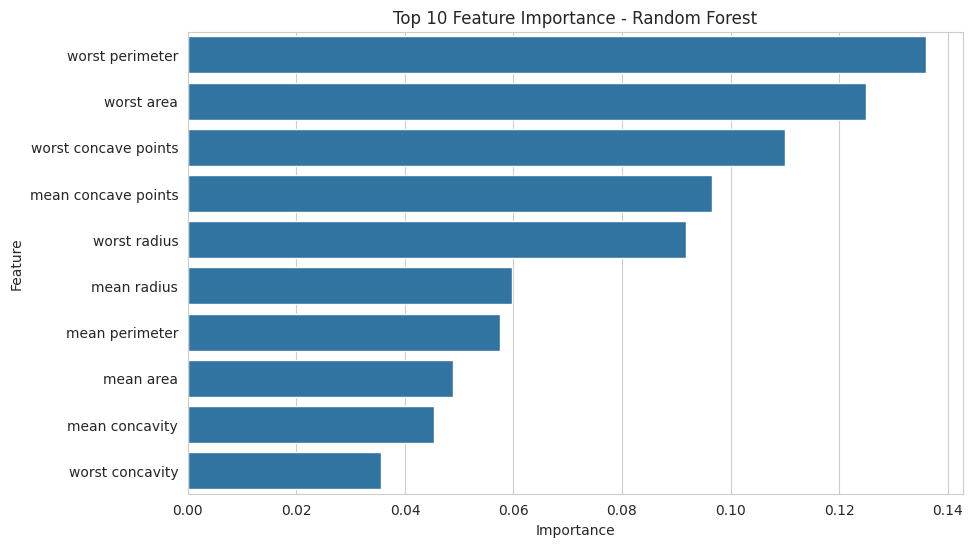

In [28]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_features, x="importance", y="feature")
plt.title("Top 10 Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## 16. Contoh Prediksi Data Baru

Setelah model selesai dilatih, kita dapat menggunakannya untuk memprediksi data baru.  
Pada contoh ini, kita mengambil satu data dari test set lalu melihat hasil prediksi model.

In [29]:
sample_data = X_test.iloc[[0]]
sample_true = y_test.iloc[0]

pred_logreg = logreg.predict(scaler.transform(sample_data))[0]
pred_rf = rf.predict(sample_data)[0]

print("Label asli :", sample_true, f"({cancer.target_names[sample_true]})")
print("Prediksi Logistic Regression :", pred_logreg, f"({cancer.target_names[pred_logreg]})")
print("Prediksi Random Forest       :", pred_rf, f"({cancer.target_names[pred_rf]})")

Label asli : 0 (malignant)
Prediksi Logistic Regression : 0 (malignant)
Prediksi Random Forest       : 0 (malignant)


# 17. Kesimpulan

Pada chapter ini, kita mempelajari beberapa model klasifikasi populer dalam scikit-learn.

## Poin penting:
1. **Classification** digunakan untuk memprediksi label kategori.
2. Data perlu dibagi menjadi **training set** dan **test set** agar evaluasi adil.
3. **Feature scaling** penting untuk model tertentu seperti Logistic Regression, KNN, dan SVM.
4. Setiap algoritma memiliki karakteristik berbeda:
   - **Logistic Regression**: sederhana, cepat, dan cocok sebagai baseline
   - **KNN**: berbasis jarak dan sensitif terhadap scaling
   - **Decision Tree**: mudah dipahami, tetapi rawan overfitting
   - **Random Forest**: lebih stabil dan kuat karena ensemble
   - **SVM**: sering memberikan performa tinggi, tetapi perlu tuning parameter

5. Evaluasi model klasifikasi tidak cukup hanya dengan accuracy.  
   Kita juga perlu melihat:
   - confusion matrix,
   - classification report,
   - ROC curve,
   - ROC-AUC.

Secara umum, chapter ini menunjukkan bahwa pemilihan model klasifikasi harus mempertimbangkan performa, interpretasi, dan karakteristik data.

In [30]:
results.to_csv("chapter6_classification_results.csv", index=False)
print("File chapter6_classification_results.csv berhasil disimpan.")

File chapter6_classification_results.csv berhasil disimpan.
